In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics

# 2. Descompactar o dataset
# Removemos a pasta antiga antes para garantir que não haja arquivos corrompidos
!rm -rf /content/test
!unzip -q /content/drive/MyDrive/PI_V/test.zip -d /content/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.4 MB/s eta 0:00:00


In [6]:
from ultralytics import YOLO

# Carrega o modelo 'Small' (yolov8s) - ele é muito melhor para identificar arroz e milho que o 'Nano'
model = YOLO('yolov8s.pt')

# Treina com 100 épocas para dar tempo do modelo aprender texturas claras (arroz/milho)
model.train(data='/content/comida.yaml', epochs=100, imgsz=640, device=0, name='treino_melhorado')

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/comida.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=treino_melhorado4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspectiv

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78a1d6e51ee0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,  

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,130,228 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2012.6±710.2 MB/s, size: 63.4 KB)
val: Scanning /content/train/labels.cache... 106 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 106/106 26.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.5it/s 4.6s
                   all        106        456      0.995      0.978      0.995      0.975
                 beans         50         50      0.995          1      0.995       0.98
                  beef         48         49      0.997          1      0.995      0.993
              broccoli         18         18       0.99          1      0.995      0.969
                carrot         43         44      0.996          1      0.995       0.95
               chicken         44         44      0.999  

Saving noodles0019.jpg to noodles0019.jpg

image 1/1 /content/noodles0019.jpg: 640x640 1 noodles, 16.2ms
Speed: 2.8ms preprocess, 16.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


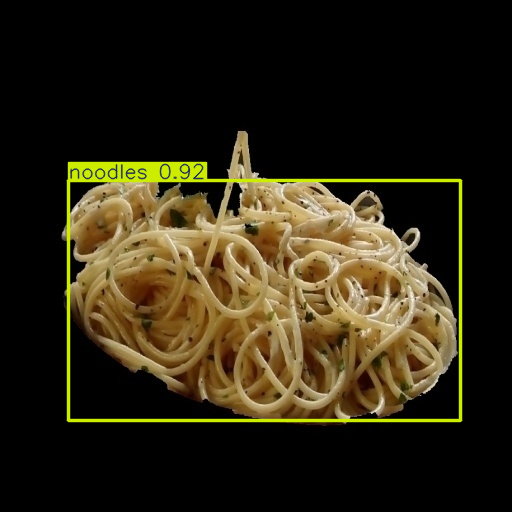

In [8]:
from ultralytics import YOLO
from google.colab import files
from google.colab.patches import cv2_imshow

# Agora apontamos para a pasta 'treino_melhorado' que criamos acima
model = YOLO('/content/runs/detect/treino_melhorado4/weights/best.pt')

# Roda a validação detalhada
metrics = model.val()

print("\n" + "="*30)
print(f"RESUMO DAS MÉTRICAS:")
print(f"Precisão (Precision): {metrics.results_dict['metrics/precision(B)']:.4f}")
print(f"Revocação (Recall): {metrics.results_dict['metrics/recall(B)']:.4f}")
print(f"mAP50: {metrics.results_dict['metrics/mAP50(B)']:.4f}")
print("="*30)

# Bloco de Teste Prático (IMPORTANTE: Baixamos a confiança para 0.15)
print("Selecione a foto para testar (Arroz, Carne e Milho):")
uploaded = files.upload()
for fn in uploaded.keys():
    # conf=0.15 força o modelo a mostrar o que ele tem "dúvida", revelando o arroz e o milho
    results = model.predict(source=fn)
    res_plotted = results[0].plot()
    cv2_imshow(res_plotted)

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,130,228 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2175.9±743.1 MB/s, size: 66.1 KB)
val: Scanning /content/train/labels.cache... 106 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 106/106 22.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.3it/s 5.2s
                   all        106        456      0.995      0.978      0.995      0.975
                 beans         50         50      0.995          1      0.995       0.98
                  beef         48         49      0.997          1      0.995      0.993
              broccoli         18         18       0.99          1      0.995      0.969
                carrot         43         44      0.996          1      0.995       0.95
               chicken         44         44      0.999  

Saving fries0028.jpg to fries0028.jpg

image 1/1 /content/fries0028.jpg: 640x640 1 beef, 1 potato, 1 rice, 16.2ms
Speed: 3.3ms preprocess, 16.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


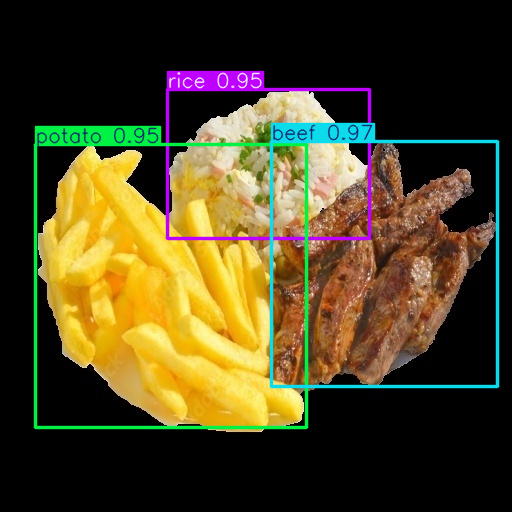

In [9]:
from ultralytics import YOLO
from google.colab import files
from google.colab.patches import cv2_imshow

# Agora apontamos para a pasta 'treino_melhorado' que criamos acima
model = YOLO('/content/runs/detect/treino_melhorado4/weights/best.pt')

# Roda a validação detalhada
metrics = model.val()

print("\n" + "="*30)
print(f"RESUMO DAS MÉTRICAS:")
print(f"Precisão (Precision): {metrics.results_dict['metrics/precision(B)']:.4f}")
print(f"Revocação (Recall): {metrics.results_dict['metrics/recall(B)']:.4f}")
print(f"mAP50: {metrics.results_dict['metrics/mAP50(B)']:.4f}")
print("="*30)

# Bloco de Teste Prático (IMPORTANTE: Baixamos a confiança para 0.15)
print("Selecione a foto para testar (Arroz, Carne e Milho):")
uploaded = files.upload()
for fn in uploaded.keys():
    # conf=0.15 força o modelo a mostrar o que ele tem "dúvida", revelando o arroz e o milho
    results = model.predict(source=fn)
    res_plotted = results[0].plot()
    cv2_imshow(res_plotted)

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,130,228 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2481.9±742.6 MB/s, size: 83.4 KB)
val: Scanning /content/train/labels.cache... 106 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 106/106 44.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.7it/s 4.2s
                   all        106        456      0.995      0.978      0.995      0.975
                 beans         50         50      0.995          1      0.995       0.98
                  beef         48         49      0.997          1      0.995      0.993
              broccoli         18         18       0.99          1      0.995      0.969
                carrot         43         44      0.996          1      0.995       0.95
               chicken         44         44      0.999  

Saving rice0030_jpg.rf.GaeOsah6oTcGZrHYX8PL.jpg to rice0030_jpg.rf.GaeOsah6oTcGZrHYX8PL.jpg

image 1/1 /content/rice0030_jpg.rf.GaeOsah6oTcGZrHYX8PL.jpg: 640x640 1 beans, 1 chicken, 1 rice, 1 salad, 16.2ms
Speed: 3.9ms preprocess, 16.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


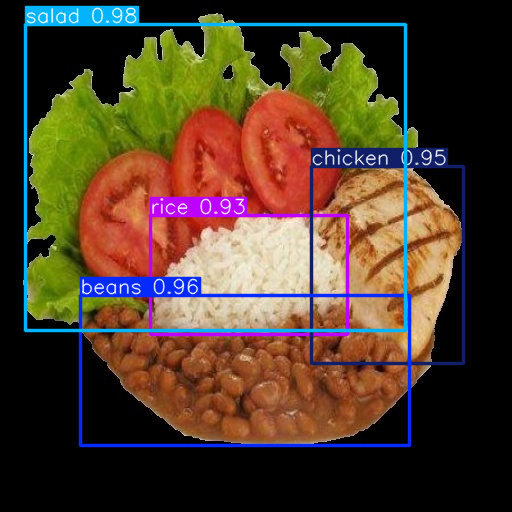

In [11]:
from ultralytics import YOLO
from google.colab import files
from google.colab.patches import cv2_imshow

# Agora apontamos para a pasta 'treino_melhorado' que criamos acima
model = YOLO('/content/runs/detect/treino_melhorado4/weights/best.pt')

# Roda a validação detalhada
metrics = model.val()

print("\n" + "="*30)
print(f"RESUMO DAS MÉTRICAS:")
print(f"Precisão (Precision): {metrics.results_dict['metrics/precision(B)']:.4f}")
print(f"Revocação (Recall): {metrics.results_dict['metrics/recall(B)']:.4f}")
print(f"mAP50: {metrics.results_dict['metrics/mAP50(B)']:.4f}")
print("="*30)

# Bloco de Teste Prático (IMPORTANTE: Baixamos a confiança para 0.15)
print("Selecione a foto para testar (Arroz, Carne e Milho):")
uploaded = files.upload()
for fn in uploaded.keys():
    # conf=0.15 força o modelo a mostrar o que ele tem "dúvida", revelando o arroz e o milho
    results = model.predict(source=fn)
    res_plotted = results[0].plot()
    cv2_imshow(res_plotted)

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,130,228 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2256.2±519.6 MB/s, size: 75.9 KB)
val: Scanning /content/train/labels.cache... 106 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 106/106 40.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.9it/s 3.7s
                   all        106        456      0.995      0.978      0.995      0.975
                 beans         50         50      0.995          1      0.995       0.98
                  beef         48         49      0.997          1      0.995      0.993
              broccoli         18         18       0.99          1      0.995      0.969
                carrot         43         44      0.996          1      0.995       0.95
               chicken         44         44      0.999  

Saving teste2.jpg to teste2.jpg

image 1/1 /content/teste2.jpg: 480x640 1 beans, 1 beef, 1 potato, 1 rice, 1 salad, 45.9ms
Speed: 2.9ms preprocess, 45.9ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


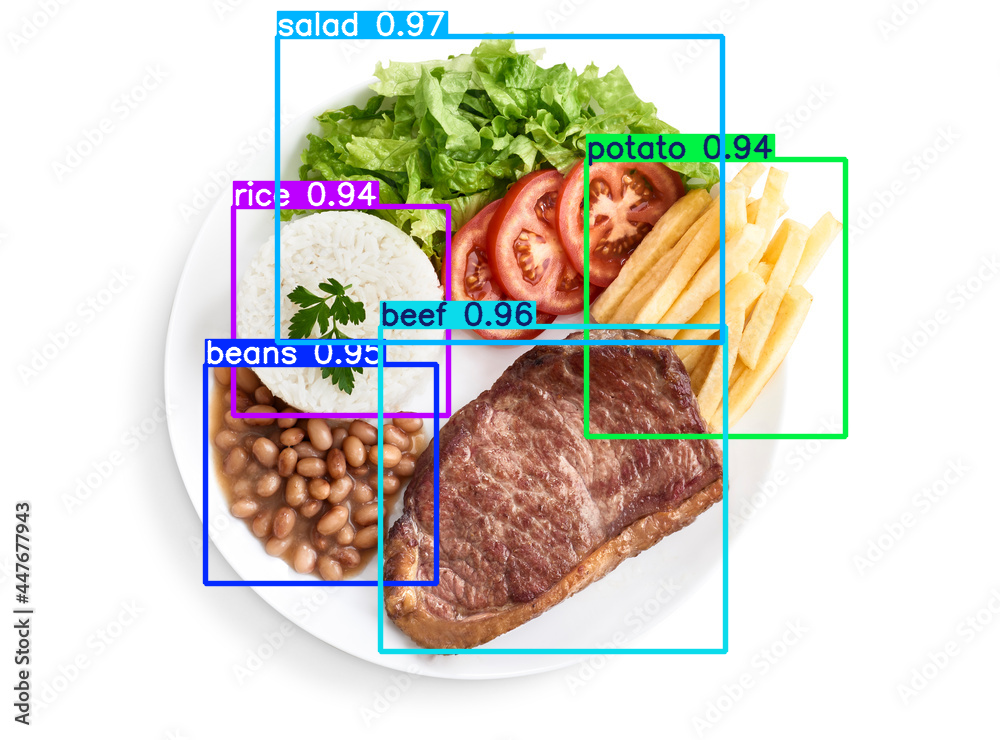

In [13]:
from ultralytics import YOLO
from google.colab import files
from google.colab.patches import cv2_imshow

# Agora apontamos para a pasta 'treino_melhorado' que criamos acima
model = YOLO('/content/runs/detect/treino_melhorado4/weights/best.pt')

# Roda a validação detalhada
metrics = model.val()

print("\n" + "="*30)
print(f"RESUMO DAS MÉTRICAS:")
print(f"Precisão (Precision): {metrics.results_dict['metrics/precision(B)']:.4f}")
print(f"Revocação (Recall): {metrics.results_dict['metrics/recall(B)']:.4f}")
print(f"mAP50: {metrics.results_dict['metrics/mAP50(B)']:.4f}")
print("="*30)

# Bloco de Teste Prático (IMPORTANTE: Baixamos a confiança para 0.15)
print("Selecione a foto para testar (Arroz, Carne e Milho):")
uploaded = files.upload()
for fn in uploaded.keys():
    # conf=0.15 força o modelo a mostrar o que ele tem "dúvida", revelando o arroz e o milho
    results = model.predict(source=fn, conf=0.3)
    res_plotted = results[0].plot()
    cv2_imshow(res_plotted)